# Machine Learning in Computational Biology
## Spring 2026 • Assignment #2
### Heart Disease Classification using Repeated Nested Cross-Validation

Maria-Despoina Liassa


- The dataset UCI Heart Disease Dataset (Cleveland subset), contains 242 patient records and 14 attributes 
    - 13 features & 1 target variable
- The task is **binary classification**: predict whether a patient has heart disease based on the target variable
num
 - num = 0 --> no heart disease  
 - num = 1 --> presence of heart disease 
 
 All provided samples will be used in building the predictive models

------------------

- The dataset has manually renamed to heart.csv
- We check the project structure and the libraries, to run properly the notebook

In [1]:
import os

# Define the project structure (relative to the main project directory)
# Since the notebook is in /notebooks, we go up one level with '..'
base_dir = ".."
required_folders = ["data", "figures", "models", "notebooks", "results", "src"]

print("--- Checking Project Structure ---")

for folder in required_folders:
    folder_path = os.path.join(base_dir, folder)
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"[CREATED] Folder: {folder}")
    else:
        print(f"[EXISTS]  Folder: {folder}")

# Check for required source files in /src
required_files = {
    "src": ["functions.py", "pipeline.py"]
}

for folder, files in required_files.items():
    for file in files:
        file_path = os.path.join(base_dir, folder, file)
        if not os.path.exists(file_path):
            print(f"[WARNING] Missing source file: {file_path}. Please ensure your code is present.")
        else:
            print(f"[OK]      Source file found: {file}")

print("----------------------------------")

--- Checking Project Structure ---
[EXISTS]  Folder: data
[EXISTS]  Folder: figures
[EXISTS]  Folder: models
[EXISTS]  Folder: notebooks
[EXISTS]  Folder: results
[EXISTS]  Folder: src
[OK]      Source file found: functions.py
[OK]      Source file found: pipeline.py
----------------------------------


In [2]:
import subprocess
import sys

def install_missing_packages():
    # Λίστα με τις απαραίτητες βιβλιοθήκες για την εργασία
    required_packages = [
        "numpy", 
        "pandas", 
        "scikit-learn", 
        "matplotlib", 
        "seaborn", 
        "xgboost", 
        "lightgbm", 
        "catboost", 
        "shap", 
        "scipy"
    ]
    
    print("--- Checking Required Libraries ---")
    
    for package in required_packages:
        try:
            # Προσπάθεια εισαγωγής της βιβλιοθήκης (μερικές έχουν διαφορετικό όνομα στο import)
            import_name = package
            if package == "scikit-learn": import_name = "sklearn"
            
            __import__(import_name)
            print(f"[OK]      {package} is already installed.")
        except ImportError:
            print(f"[INSTALL] {package} not found. Installing...")
            # Εκτέλεση της εγκατάστασης μέσω pip
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"[DONE]    {package} installed successfully.")

    print("-----------------------------------\n")

# Εκτέλεση της συνάρτησης
install_missing_packages()

--- Checking Required Libraries ---
[OK]      numpy is already installed.
[OK]      pandas is already installed.
[OK]      scikit-learn is already installed.
[OK]      matplotlib is already installed.
[OK]      seaborn is already installed.
[OK]      xgboost is already installed.
[OK]      lightgbm is already installed.
[OK]      catboost is already installed.
[INSTALL] shap not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 6.8 MB/s  0:00:00m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 9.4 MB/s  0:00:05m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 9.0 MB/s  0:00:00m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [shap]4/5 [shap]]te]
[DONE]    shap installed successfully.
[OK]      scipy is already installed.
-----------------------------------



----------

## Task 1 :Exploratory Analysis


In [ ]:
# Library imports
import sys

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


### Task 1.1 
Import, Overview and Descriptive Statistics of data

In [2]:
# Add the src directory to the path to import the functions
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(os.path.join(module_path, 'src'))

from functions import load_heart_disease_data, overview, get_data_summary

# Definition of the path for the dataset
# We use '../data/heart.csv' because the notebook is located inside the notebooks folder
data_path = "../data/heart.csv"

# Load the data
df = load_heart_disease_data(data_path)

# Εμφάνιση των πρώτων 10 γραμμών
display(overview(df))

# Get and display the data summary
summary = get_data_summary(df)

print(f"Dataset Shape: {summary['shape']}")

print("\n--- Data Types ---")
print(summary['dtypes'])

print(f"\nDuplicate Records: {summary['duplicates']}")
print("\n--- Class Balance (%) ---")
print(summary['class_balance'])

print("\n--- Missing Values by Column ---")
print(summary['missing_values'])



--- First 10 Rows of the Dataset ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,48.0,1.0,4.0,124.0,274.0,0.0,2.0,166.0,0.0,0.5,2.0,0.0,7.0,1
1,55.0,1.0,2.0,130.0,262.0,0.0,0.0,155.0,0.0,0.0,1.0,0.0,3.0,0
2,54.0,0.0,2.0,132.0,288.0,1.0,2.0,159.0,1.0,0.0,1.0,1.0,3.0,0
3,54.0,1.0,2.0,108.0,309.0,0.0,0.0,156.0,0.0,0.0,1.0,0.0,7.0,0
4,57.0,0.0,4.0,140.0,241.0,0.0,0.0,123.0,1.0,0.2,2.0,0.0,7.0,1
5,48.0,1.0,4.0,130.0,256.0,1.0,2.0,150.0,1.0,0.0,1.0,2.0,7.0,1
6,54.0,1.0,4.0,124.0,266.0,0.0,2.0,109.0,1.0,2.2,2.0,1.0,7.0,1
7,55.0,1.0,4.0,140.0,217.0,0.0,0.0,111.0,1.0,5.6,3.0,0.0,7.0,1
8,65.0,0.0,3.0,155.0,269.0,0.0,0.0,148.0,0.0,0.8,1.0,0.0,3.0,0
9,46.0,1.0,4.0,140.0,311.0,0.0,0.0,120.0,1.0,1.8,2.0,2.0,7.0,1


Dataset Shape: (242, 14)

--- Data Types ---
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Duplicate Records: 0

--- Class Balance (%) ---
target
0    54.132231
1    45.867769
Name: proportion, dtype: float64

--- Missing Values by Column ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          1
thal        1
target      0
dtype: int64


1. Structure and Data Types
- Dimensions: The dataset consists of 242 samples and 13 features (after converting "num" to "target")
- Data Types: All variables are represented as float64, except from target(int64). Although numerically they are floats, variables such as sex, cp, fbs, restecg, exang, slope, ca, and thal are actually categorical or ordinal
2. Data Quality
- Missing Values: There are very few missing values (1 value in the "ca" column and 1 in the "thal" column)
    - We will use an imputer (e.g. SimpleImputer with mean or median) to ensure no data leakage
- Duplicates: No duplicate records were found, so no rows need to be dropped
3. Class Balance
- The distribution is approximately 54.1% (healthy) and 45.9% (patients)
- The dataset is considered relatively balanced
4. Initial Observations 
- The values of the continuous variables (e.g. chol, thalach) have different scales (e.g. cholesterol reaches 311 while oldpeak is 1.8)
    - This leads us to use Scaling 

### Task 1.2 
Feature Assessment and Visualization 

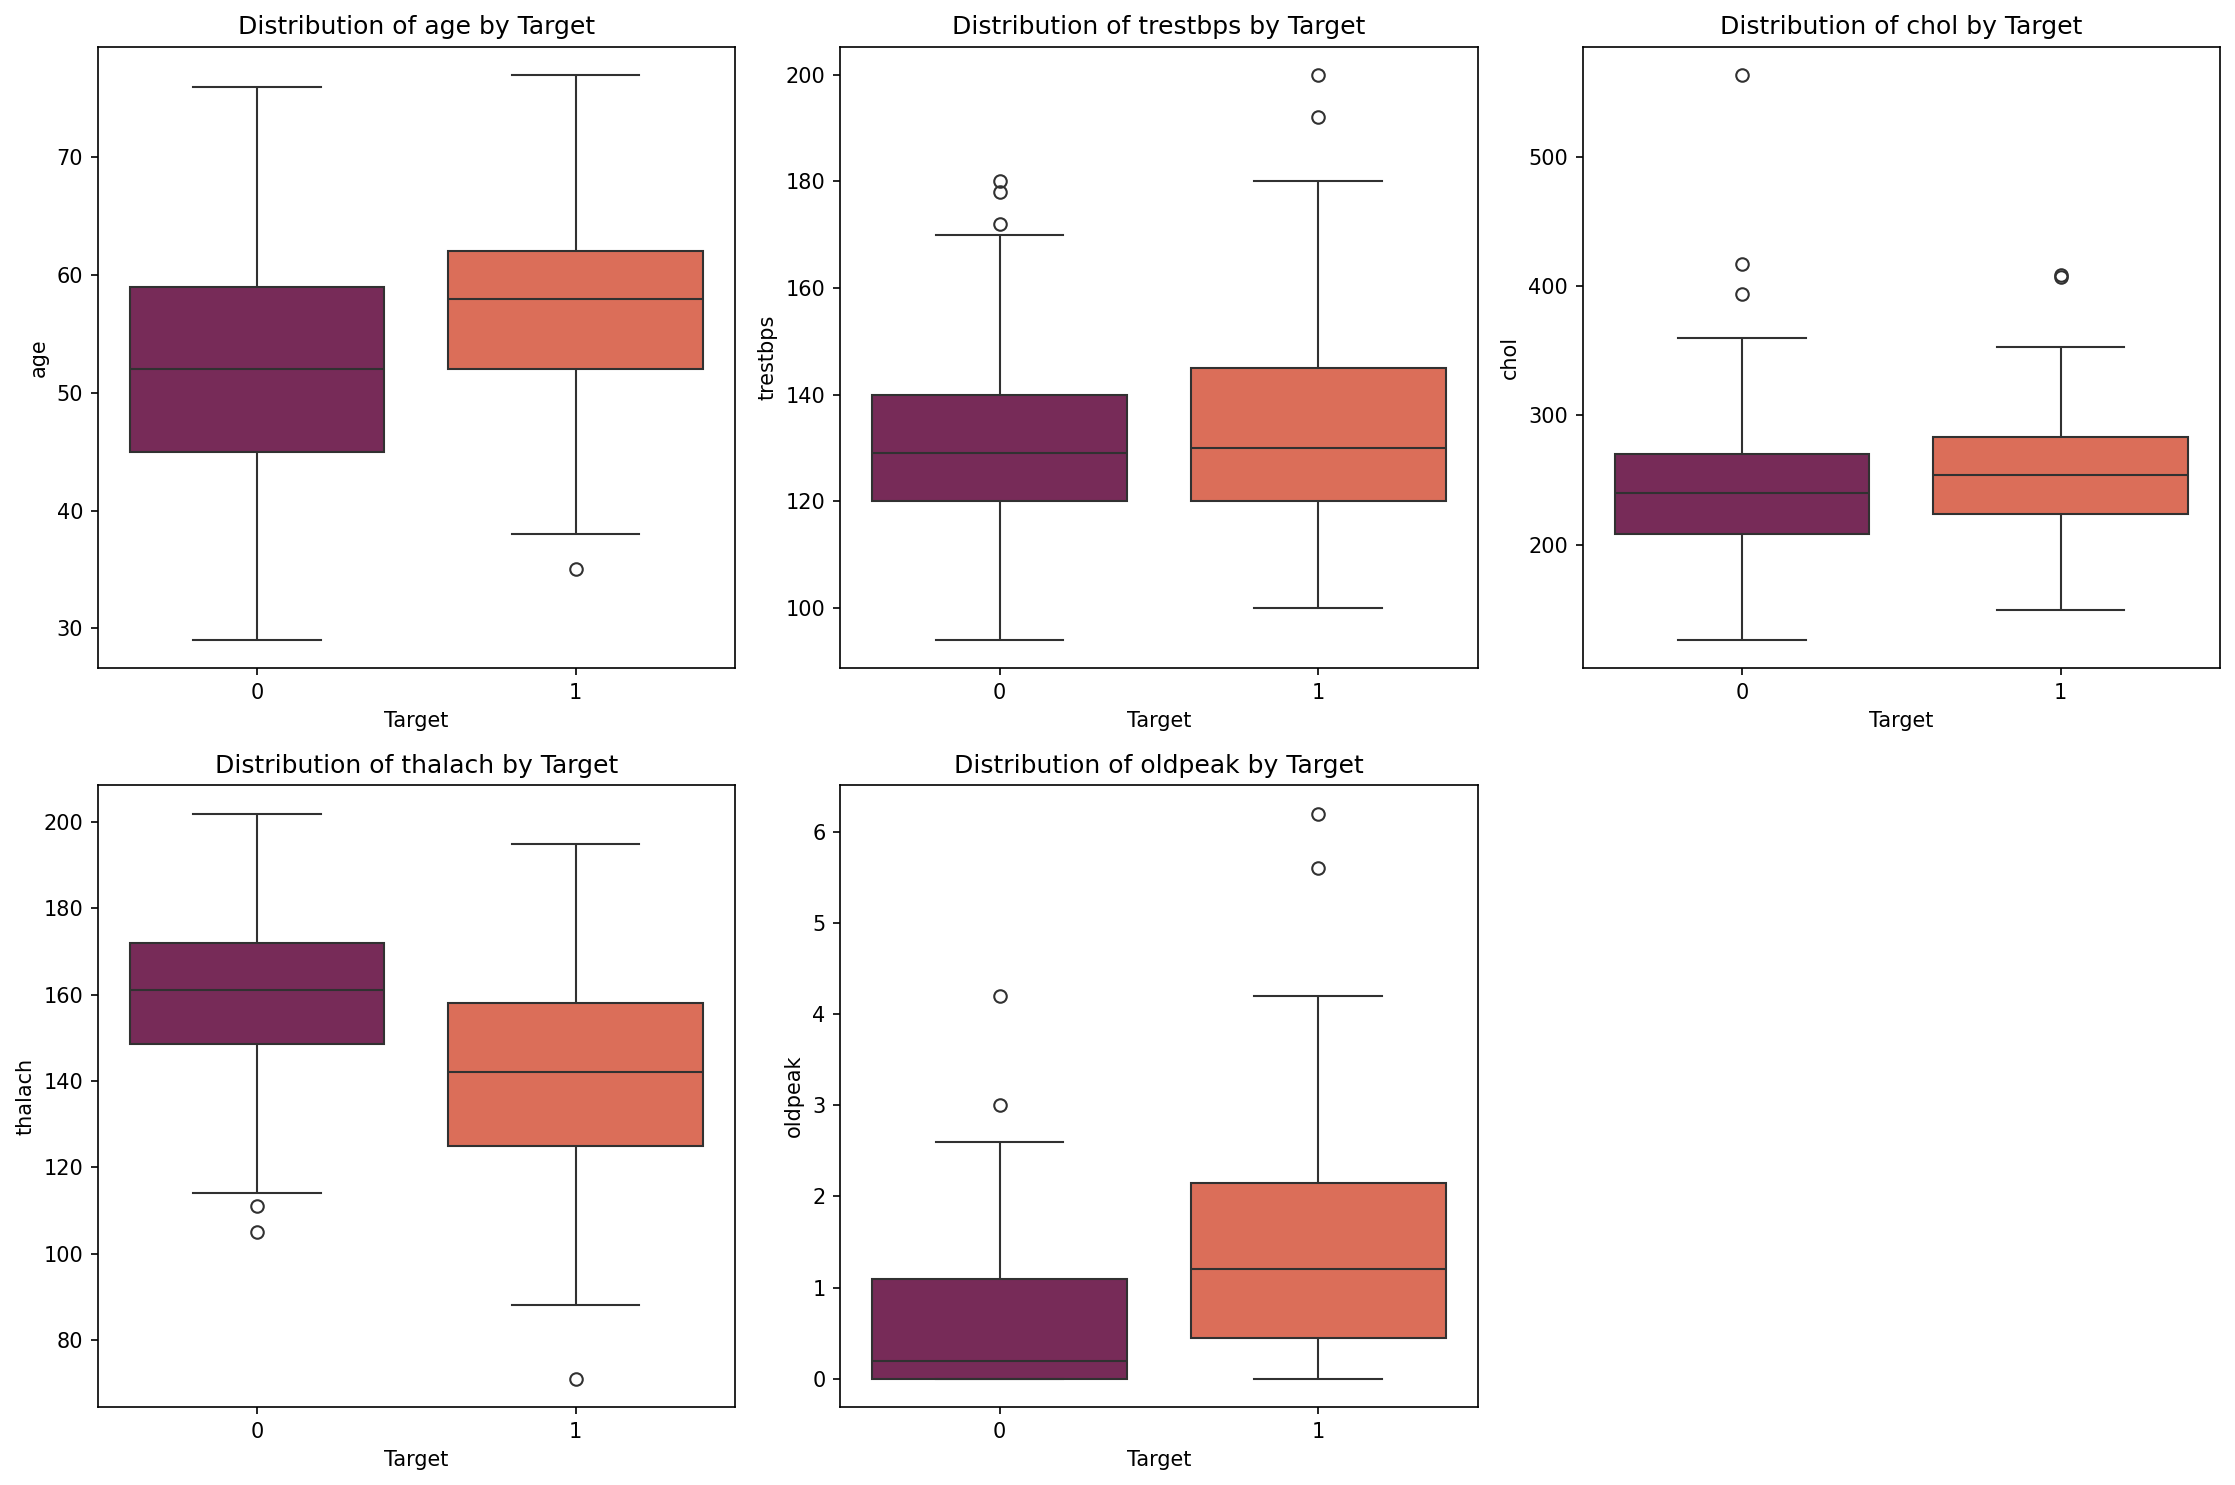

In [3]:
# Continuous variables
continuous_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10), dpi=150)

for i, feature in enumerate(continuous_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
        data=df, 
        y=feature, 
        x='target', 
        hue='target', 
        palette='rocket', 
        legend=False
    )
    # Title & labels
    plt.xlabel('Target', fontsize=10)
    plt.ylabel(feature, fontsize=10)
    plt.title(f'Distribution of {feature} by Target')

plt.tight_layout()

# Save image in figures
plot_path = '../figures/Continuous Features by Target.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

Correlation Heatmap

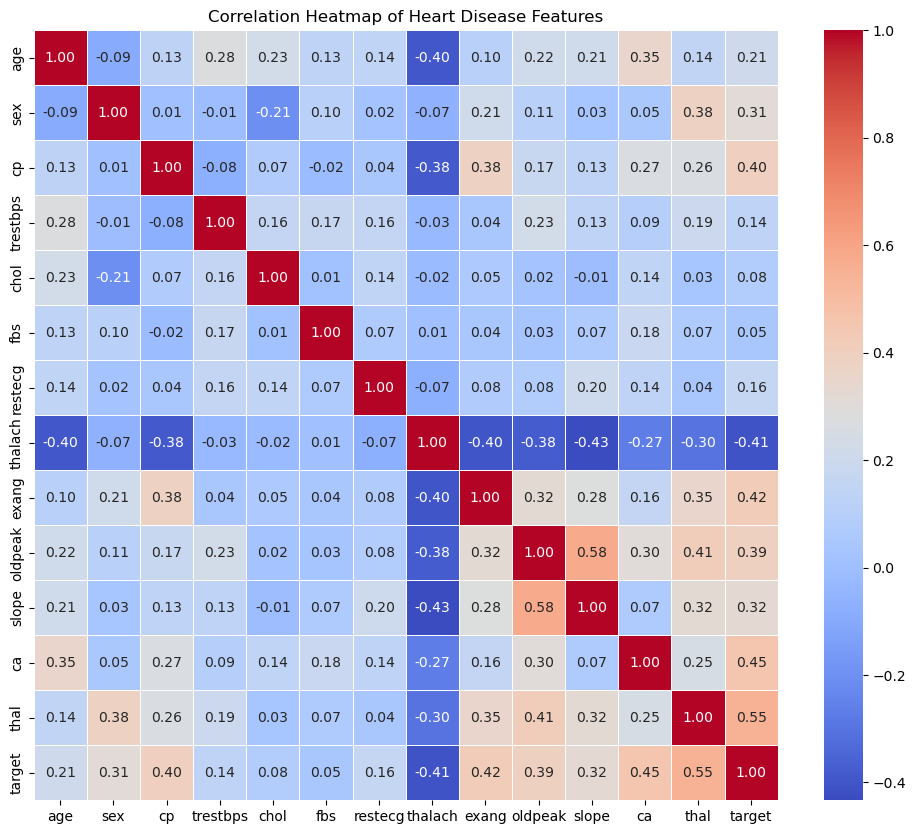

Saved graph to: ../images/correlation_heatmap.png


<Figure size 640x480 with 0 Axes>

In [ ]:
from functions import plot_correlation_heatmap

save_file = "../images/correlation_heatmap.png"
# Create the correlation heatmap and save it
plot_correlation_heatmap(df, save_path=save_file)



Observing the Correlation Heatmap : 
- Strong predictors of heart disease are the features `thal`, `ca`, `exang` και `cp`show the strongest positive correlation with `target`
(0.55 , 0.45 , 0.42 , 0.40 respectively)
- Negative correlation  of of `thalach` (-0.41) confirms that a low maximum heart rate is a clinical risk indicator
- Feature Selection technique is justified as a next step, to simplify model's complexity, since we observe low correlation between some variables (`fbs`, `chol`) and the `target` variable 


We perform **PCA** in EDA analysis to understand 'class separability' (For EDA we do it on the whole df for visualization, but in modeling it should be inside the Pipeline)

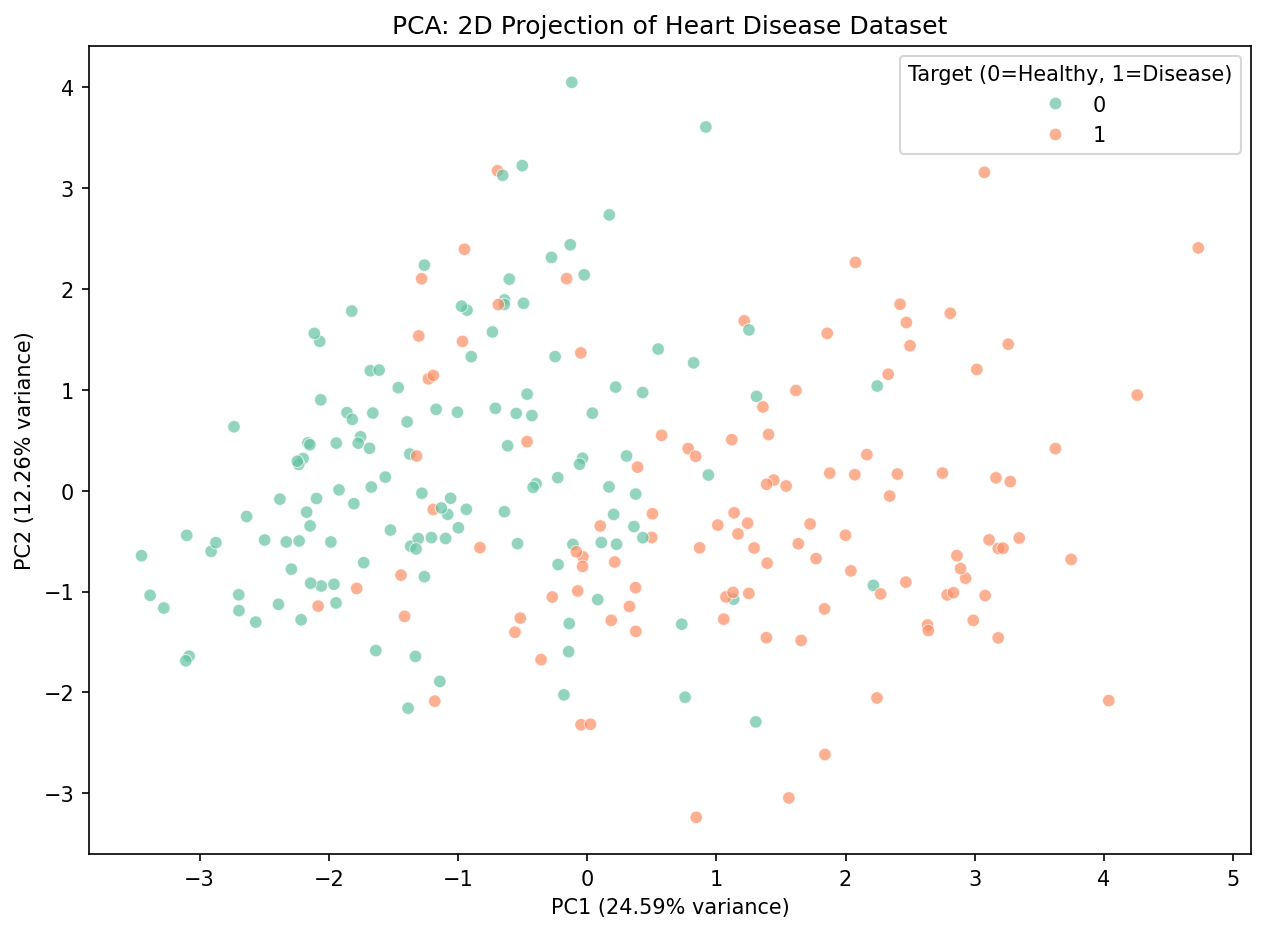

In [6]:
# 1.Preparation of data for PCA by separating features and target 
X_temp = df.drop(columns=['target'])
y_temp = df['target']

# 2. Scaling for PCA (Standardization)
X_scaled = StandardScaler().fit_transform(X_temp.fillna(X_temp.median())) # Temporary fillna for plot purposes

# 3. PCA για 2 components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

# 4. Visualization of PCA results
# 150 dpi quality
plt.figure(figsize=(10, 7), dpi=150)
sns.scatterplot(x=pca_results[:,0], y=pca_results[:,1], hue=y_temp, palette='Set2', alpha=0.7)

# Title & labels
plt.title('PCA: 2D Projection of Heart Disease Dataset')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')

plt.legend(title='Target (0=Healthy, 1=Disease)')

# Save image in figures
plot_path = '../figures/PCA _EDA_Projection.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

- We observe a clear trend of separation along the PC1 axis, with healthy samples primarily located in the negative values and patients in the positive values 
    - However, a significant **overlap is observed in the center**, indicating that the data cannot be linearly separated in a simple manner
- Approximately 37% of the information is captured by the first two components. The remaining information is distributed across the other dimensions, suggesting that the model would benefit from the full set of features or from careful **Feature Selection**, as we also suspected from the Correlation Heatmap results

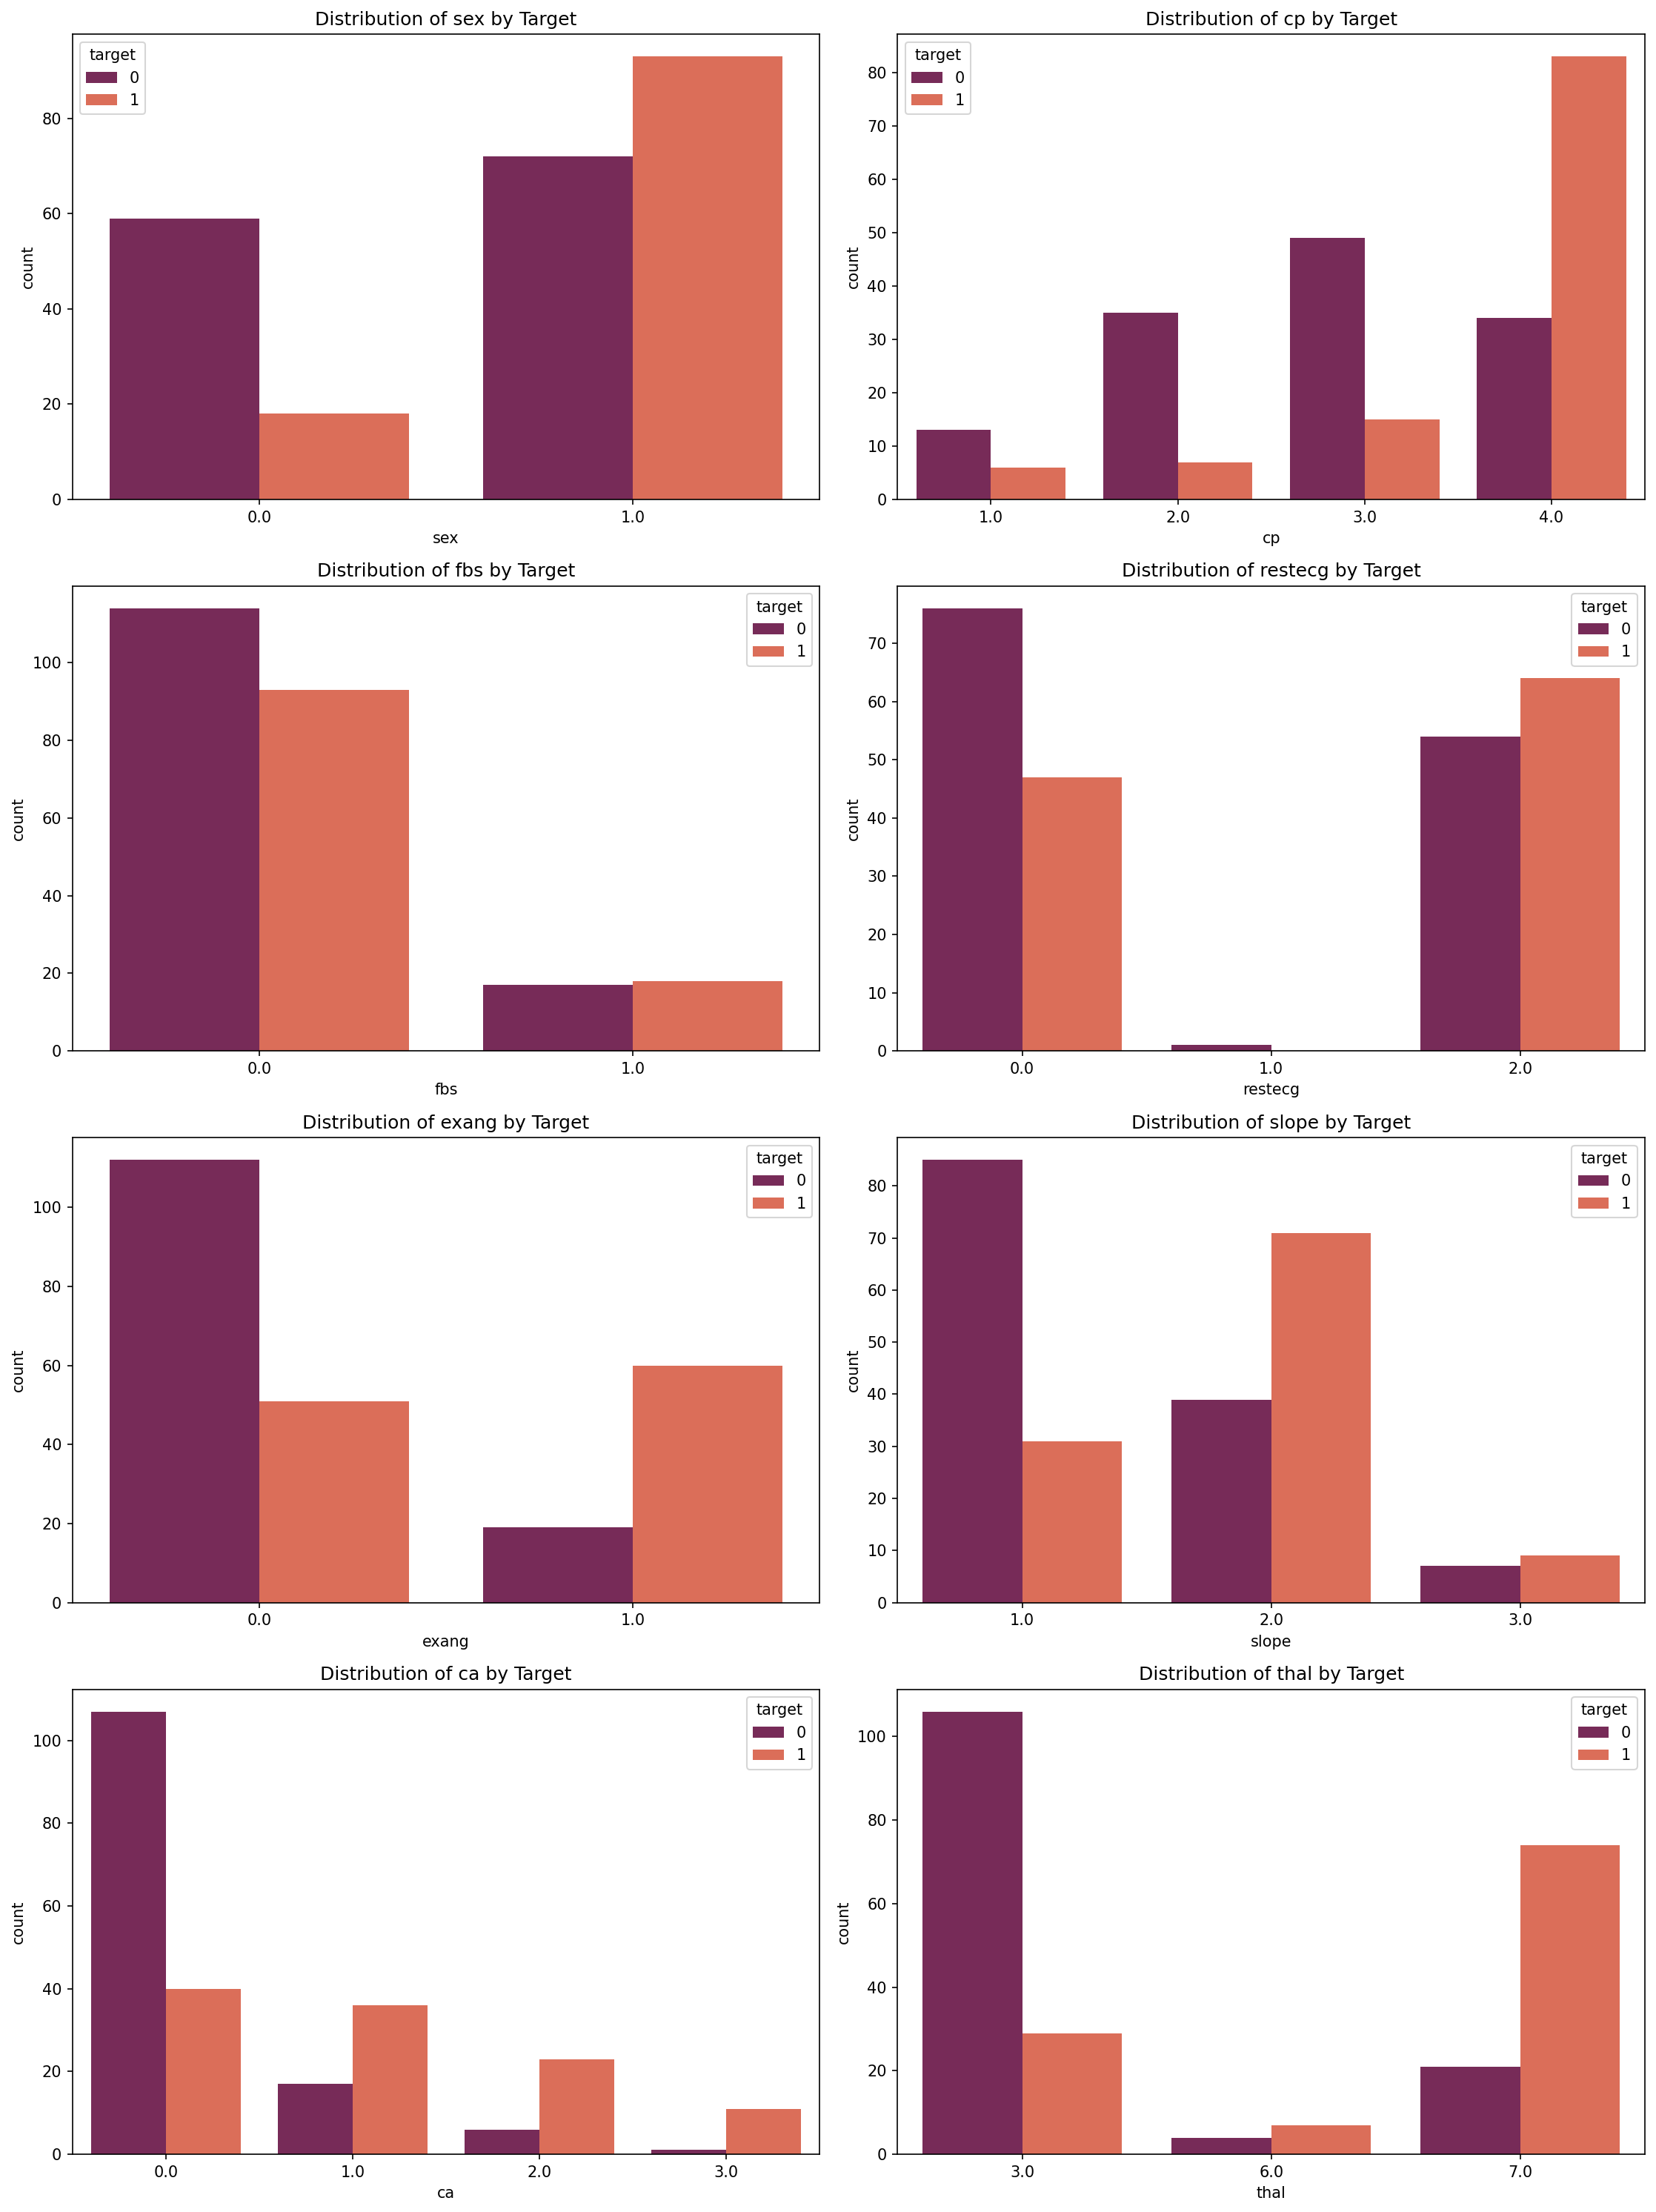

In [ ]:
from functions import plot_categorical_distributions

# Categorical, binary and ordinal variables to plot
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

plot_categorical_distributions(df, categorical_cols) # save path is defined inside the function

Counts plots of categorical variables, revealed the following conclusions 

- Strong predictive features : Characteristics such as the type of chest pain (`cp`), the number of large vessels (`ca`), and the type of thalassemia (`thal`) show a clear distinction between classes
- Categories with a limited number of samples require the use of **Stratified K-Fold** to preserve the class distribution
- Missing values identified (e.g., in `ca` and `thal`) will be handled via **Imputation** within the pipeline to prevent data leakage